Raw Data
    ↓
Cleaning
    ↓
Encoding
    ↓
X and y
    ↓
Train-Test Split
    ↓
Scaling
    ↓
Model
    ↓
Prediction
    ↓
Evaluation

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"C:\Users\shobh\OneDrive\Attachments\Documents\Desktop\py\Salary Data.csv")

df = pd.DataFrame(data)

In [3]:
# lets start 

df.sample(5)

df.columns

df.head(5)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [4]:
# lets clean the data 


df.isnull().sum()

df.dropna(inplace=True)

In [5]:
df.isnull().sum()

df.duplicated().sum()

df.drop_duplicates(inplace=True)

In [6]:
# data cleaned now 
df.duplicated().sum()

df.isnull().sum()


Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

C:\Users\shobh\AppData\Local\Temp\ipykernel_17840\3963165110.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20['Years of Experience'],y=top20['Salary'], palette = 'rainbow')


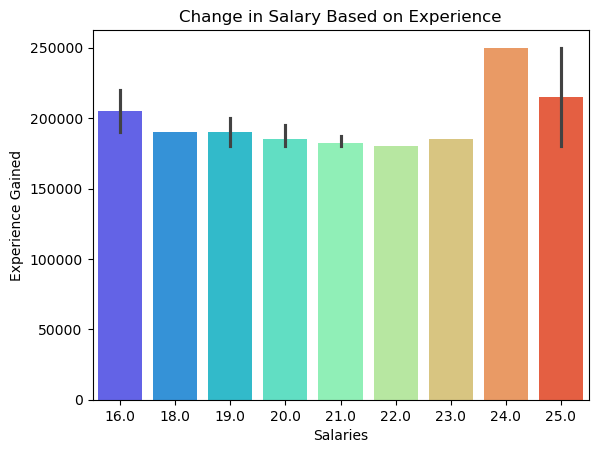

In [7]:
#understand the dataset

# change in salary wuth experience

top20 = df.sort_values(by='Salary',ascending=False).head(20)

sns.barplot(x=top20['Years of Experience'],y=top20['Salary'], palette = 'rainbow')

plt.title("Change in Salary Based on Experience")

plt.xlabel("Salaries")
plt.ylabel("Experience Gained")


plt.savefig(r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\Employee Salary Predictor\Graphs Used\salary_experience_comparision.png",
            dpi = 300 , bbox_inches= "tight" )

C:\Users\shobh\AppData\Local\Temp\ipykernel_17840\2503764079.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=final.index,y=final.values,palette='Set2')


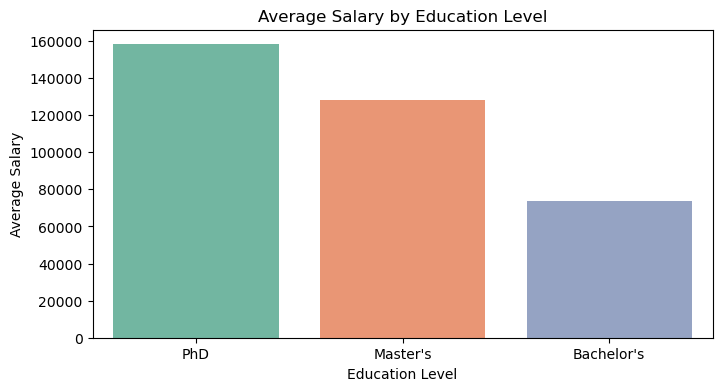

In [8]:
# Which education level earns the most?

final = df.groupby('Education Level')['Salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x=final.index,y=final.values,palette='Set2')

plt.title("Average Salary by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Salary")

plt.savefig(r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\Employee Salary Predictor\Graphs Used\Education_Level_Comparision.png",
            dpi = 300 , bbox_inches= "tight" )

plt.show()


C:\Users\shobh\AppData\Local\Temp\ipykernel_17840\1977159103.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='rainbow')


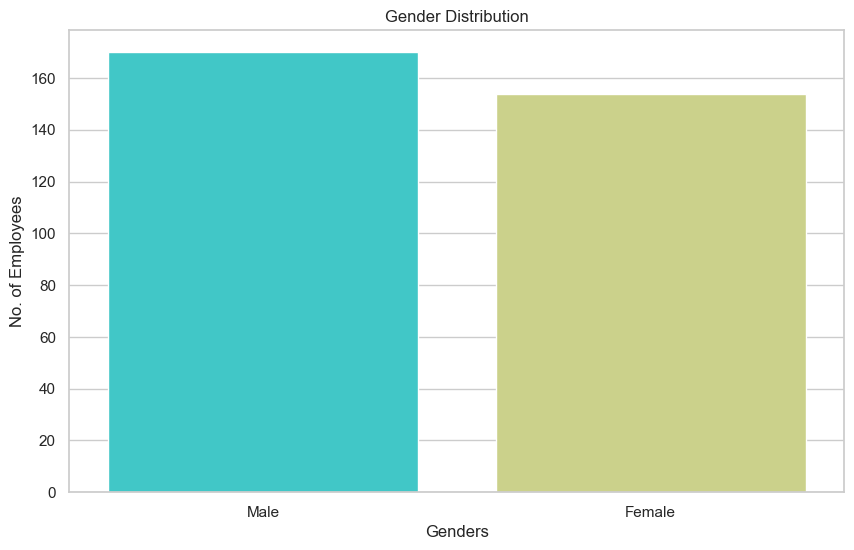

In [9]:
#Gender Distribution 

gender = df['Gender']

plt.figure ( figsize = (10,6))
sns.set_theme(style="whitegrid")
sns.countplot(x='Gender', data=df, palette='rainbow')

plt.title("Gender Distribution")
plt.xlabel("Genders")
plt.ylabel("No. of Employees")

plt.savefig(r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\Employee Salary Predictor\Graphs Used\Gender Distribution.png",
            dpi = 300 , bbox_inches= "tight" )

plt.show()


In [10]:
#encoding - One hot Encoding
df_label = df.copy()

df_encoded = pd.get_dummies(df_label , columns = ['Gender','Education Level','Job Title'],drop_first=True) 

df_encoded



#letas convert bool to numeric


bool_cols = df_encoded.select_dtypes(bool).columns

df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

df_encoded.sample(3)

,Age,Years of Experience,Salary,Gender_Male,Education Level_Master's,Education Level_PhD,Job Title_Accountant,Job Title_Administrative Assistant,Job Title_Business Analyst,Job Title_Business Development Manager,...,Job Title_Supply Chain Manager,Job Title_Technical Recruiter,Job Title_Technical Support Specialist,Job Title_Technical Writer,Job Title_Training Specialist,Job Title_UX Designer,Job Title_UX Researcher,Job Title_VP of Finance,Job Title_VP of Operations,Job Title_Web Developer
119,35.0,10.0,120000.0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
259,29.0,1.5,350.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
131,29.0,3.0,45000.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
# encoding now now providing features and target to model 

X = df_encoded.drop('Salary', axis=1)

y = df_encoded['Salary']



In [ ]:
df

In [12]:
# now next step is Test-Train Split 

from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test =  train_test_split(X,y,test_size = 0.2 , random_state=42)



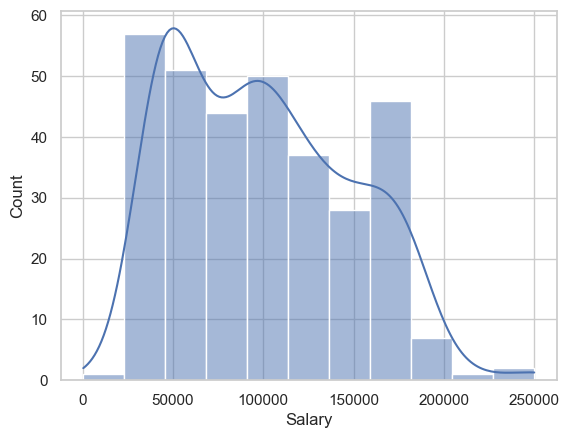

In [13]:
# now feature scaling to Standardize feature ranges

# checking distribution of the data to ecide wheater use Minmax or Strandred Scaler 

sns.histplot(df_encoded['Salary'], kde=True)

plt.show()

#its bell curved so we are using StrandredScaler since we have also to use LinearRegression lATERly 



In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)

In [15]:
# scaling done now model building

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train ,y_train)

y_pred = model.predict(X_test)

In [16]:
# model building done now Evaluation

from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))

mse = mean_squared_error(y_test, y_pred)

print("MSE :", mse)

print("R2 Score:", r2_score(y_test, y_pred))

rmse = np.sqrt(mse)
print("RMSE:", rmse)


MAE: 12404.61618939214
MSE : 254850857.426696
R2 Score: 0.8651430770660367
RMSE: 15964.048904544736


In [17]:
# evrything done 

#now lets check actual vs predicted 

final_data = {'Actual': y_test,
              'Predicted': y_pred}

comparison = pd.DataFrame(final_data)

comparison.head(10)

,Actual,Predicted
132,100000.0,112947.855675
108,100000.0,111855.627073
137,50000.0,73107.455155
9,110000.0,118709.715458
181,105000.0,109671.114928
126,95000.0,102581.743996
221,45000.0,73982.256631
198,55000.0,60974.061676
279,180000.0,174586.557418
144,40000.0,45751.440217


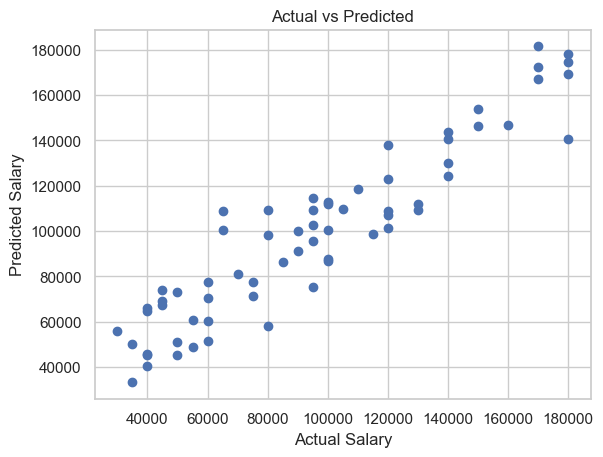

In [18]:
# graph of comparision 

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")

plt.savefig(r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗠𝗟 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\Employee Salary Predictor\Graphs Used\Actuall vs Model Prediction.png",
            dpi = 300 , bbox_inches= "tight" )
plt.show()

In [19]:
model_columns = X.columns
print(model_columns)

Index(['Age', 'Years of Experience', 'Gender_Male', 'Education Level_Master's',
       'Education Level_PhD', 'Job Title_Accountant',
       'Job Title_Administrative Assistant', 'Job Title_Business Analyst',
       'Job Title_Business Development Manager',
       'Job Title_Business Intelligence Analyst',
       ...
       'Job Title_Supply Chain Manager', 'Job Title_Technical Recruiter',
       'Job Title_Technical Support Specialist', 'Job Title_Technical Writer',
       'Job Title_Training Specialist', 'Job Title_UX Designer',
       'Job Title_UX Researcher', 'Job Title_VP of Finance',
       'Job Title_VP of Operations', 'Job Title_Web Developer'],
      dtype='object', length=178)


In [23]:
# now lets build system so that people can predict their salary too


experience = float(input("Enter Years of Experience: "))

age = int(input("Enter Age: "))

gender = input("Enter Gender (Male/Female): ")

education = input("Enter Education Level: ")

job_title = input("Enter Job Title: ")



model_columns = X.columns

user_data = pd.DataFrame(0, index=[0], columns=model_columns)



user_data['Age'] = age
user_data['Years of Experience'] = experience

if gender == "Female":
    user_data['Gender_Female'] = 1

if education == "Master's":
    user_data["Education Level_Master's"] = 1

if education == "PhD":
    user_data["Education Level_PhD"] = 1

user_data = scaler.transform(user_data)

salary = model.predict(user_data)

print(f"Predicted Salary: ₹{salary[0].round(1)}")

Enter Years of Experience:  4
Enter Age:  23
Enter Gender (Male/Female):  Male
Enter Education Level:  Phd
Enter Job Title:  UX Researcher


Predicted Salary: ₹57951.9
